# Movie Recommendation System - Part 5: Model Comparison & Evaluation

This notebook compares the recommendation models implemented across all previous notebooks in a single place.
We evaluate Collaborative Filtering (SVD), Content-Based Filtering (Genome similarity), and the Hybrid Model on:
- **RMSE** and **MAE** prediction error (evaluated on a test rating sample).
- **Precision@10** and **Recall@10** recommendation quality metrics (evaluated on test users).

Finally, we plot a comparison chart and draw a final comparison table of the recommendation paradigms.


### Step 1: Import Required Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')


### Step 2: Load Sampled Datasets, SVD Model, and Similarity Matrix


In [2]:
movies = pd.read_csv('movies_sampled.csv')
ratings = pd.read_csv('ratings_sampled.csv')

with open('surprise_svd_model.pkl', 'rb') as f:
    svd = pickle.load(f)
    
genome_sim = np.load('genome_similarity.npy')
genome_movie_ids = np.load('genome_movie_ids.npy').tolist()
movie_id_to_genome_idx = {movie_id: idx for idx, movie_id in enumerate(genome_movie_ids)}

print(f'Loaded {len(movies)} movies and datasets successfully.')


Loaded 3159 movies and datasets successfully.


### Step 3: Define Blended Scoring & Recommendation Helper Functions


In [3]:
def get_user_favorites(user_id, ratings_df):
    user_ratings = ratings_df[ratings_df['userId'] == user_id]
    high_rated = user_ratings[user_ratings['rating'] >= 4.0]
    if high_rated.empty:
        high_rated = user_ratings
    return high_rated['movieId'].tolist()

def get_hybrid_score(user_id, movie_id, user_favs, alpha=0.5):
    pred = svd.predict(user_id, movie_id)
    collab_score = (pred.est - 0.5) / 4.5
    
    if movie_id in movie_id_to_genome_idx and user_favs:
        target_idx = movie_id_to_genome_idx[movie_id]
        fav_indices = [movie_id_to_genome_idx[mid] for mid in user_favs if mid in movie_id_to_genome_idx]
        if fav_indices:
            content_score = np.mean(genome_sim[target_idx, fav_indices])
        else:
            content_score = 0.0
    else:
        content_score = 0.0
        
    return alpha * collab_score + (1.0 - alpha) * content_score


### Step 4: Evaluate Rating Prediction (RMSE & MAE) on Test Split
We compare SVD rating prediction vs. Hybrid rating prediction (mapping the hybrid score back to the 0.5 - 5.0 scale).


In [4]:
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(ratings, test_size=0.2, random_state=42)

# Pick a sample of 2000 test ratings for quick evaluation
eval_ratings = test_df.sample(n=2000, random_state=42)

svd_preds = []
hybrid_preds = []
actuals = []

user_train_favs = {}
for uid in eval_ratings['userId'].unique():
    user_train_favs[uid] = get_user_favorites(uid, train_df)
    
for _, row in eval_ratings.iterrows():
    uid = row['userId']
    mid = row['movieId']
    actual = row['rating']
    
    # SVD rating prediction
    pred_svd = svd.predict(uid, mid).est
    svd_preds.append(pred_svd)
    
    # Hybrid prediction scaled back to rating values [0.5, 5]
    h_score = get_hybrid_score(uid, mid, user_train_favs[uid], alpha=0.5)
    pred_hybrid = h_score * 4.5 + 0.5
    hybrid_preds.append(pred_hybrid)
    
    actuals.append(actual)
    
svd_rmse = np.sqrt(np.mean((np.array(svd_preds) - np.array(actuals))**2))
svd_mae = np.mean(np.abs(np.array(svd_preds) - np.array(actuals)))

hybrid_rmse = np.sqrt(np.mean((np.array(hybrid_preds) - np.array(actuals))**2))
hybrid_mae = np.mean(np.abs(np.array(hybrid_preds) - np.array(actuals)))

print(f'SVD Model Test RMSE: {svd_rmse:.4f} | MAE: {svd_mae:.4f}')
print(f'Hybrid Model Test RMSE: {hybrid_rmse:.4f} | MAE: {hybrid_mae:.4f}')


SVD Model Test RMSE: 0.6641 | MAE: 0.5073
Hybrid Model Test RMSE: 0.7726 | MAE: 0.6007


### Step 5: Evaluate Recommendation Quality (Precision@10 & Recall@10)
We evaluate the top-10 recommended movies for a set of 50 test users. Items with rating $\ge 3.5$ are considered relevant.


In [5]:
np.random.seed(42)
test_users = np.random.choice(ratings['userId'].unique(), size=50, replace=False)

k = 10
threshold = 3.5

collab_precisions = []
collab_recalls = []
content_precisions = []
content_recalls = []
hybrid_precisions = []
hybrid_recalls = []

for uid in test_users:
    user_train = train_df[train_df['userId'] == uid]
    user_test = test_df[test_df['userId'] == uid]
    test_mids = user_test['movieId'].tolist()
    if not test_mids:
        continue
        
    actual_ratings = dict(zip(user_test['movieId'], user_test['rating']))
    user_favs = user_train_favs.get(uid, [])
    
    # 1. Collaborative Predictions
    collab_rank = []
    for mid in test_mids:
        collab_rank.append((mid, svd.predict(uid, mid).est))
    collab_rank.sort(key=lambda x: x[1], reverse=True)
    
    # 2. Content-Based Predictions
    content_rank = []
    for mid in test_mids:
        if mid in movie_id_to_genome_idx and user_favs:
            target_idx = movie_id_to_genome_idx[mid]
            fav_indices = [movie_id_to_genome_idx[f] for f in user_favs if f in movie_id_to_genome_idx]
            sim = np.mean(genome_sim[target_idx, fav_indices]) if fav_indices else 0.0
        else:
            sim = 0.0
        content_rank.append((mid, sim))
    content_rank.sort(key=lambda x: x[1], reverse=True)
    
    # 3. Hybrid Predictions
    hybrid_rank = []
    for mid in test_mids:
        hybrid_rank.append((mid, get_hybrid_score(uid, mid, user_favs, alpha=0.5)))
    hybrid_rank.sort(key=lambda x: x[1], reverse=True)
    
    def get_metrics(ranked_list):
        top_k = ranked_list[:k]
        n_rel = sum(1 for mid in test_mids if actual_ratings[mid] >= threshold)
        n_rec_k = len(top_k)
        n_rel_and_rec_k = sum(1 for mid, _ in top_k if actual_ratings[mid] >= threshold)
        
        prec = n_rel_and_rec_k / n_rec_k if n_rec_k > 0 else 0
        rec = n_rel_and_rec_k / n_rel if n_rel > 0 else 0
        return prec, rec
        
    cp, cr = get_metrics(collab_rank)
    collab_precisions.append(cp)
    collab_recalls.append(cr)
    
    ctp, ctr = get_metrics(content_rank)
    content_precisions.append(ctp)
    content_recalls.append(ctr)
    
    hp, hr = get_metrics(hybrid_rank)
    hybrid_precisions.append(hp)
    hybrid_recalls.append(hr)
    
avg_collab_p = np.mean(collab_precisions)
avg_collab_r = np.mean(collab_recalls)
avg_content_p = np.mean(content_precisions)
avg_content_r = np.mean(content_recalls)
avg_hybrid_p = np.mean(hybrid_precisions)
avg_hybrid_r = np.mean(hybrid_recalls)

print(f'Collaborative SVD -> Avg Precision@10: {avg_collab_p:.4f} | Recall@10: {avg_collab_r:.4f}')
print(f'Content-Based (Genome) -> Avg Precision@10: {avg_content_p:.4f} | Recall@10: {avg_content_r:.4f}')
print(f'Hybrid Recommender -> Avg Precision@10: {avg_hybrid_p:.4f} | Recall@10: {avg_hybrid_r:.4f}')


Collaborative SVD -> Avg Precision@10: 0.9700 | Recall@10: 0.0851
Content-Based (Genome) -> Avg Precision@10: 0.7460 | Recall@10: 0.0649
Hybrid Recommender -> Avg Precision@10: 0.9560 | Recall@10: 0.0839


### Step 6: Plot Metric Comparisons
Plot the Precision@10 and Recall@10 for the three systems side-by-side using matplotlib.


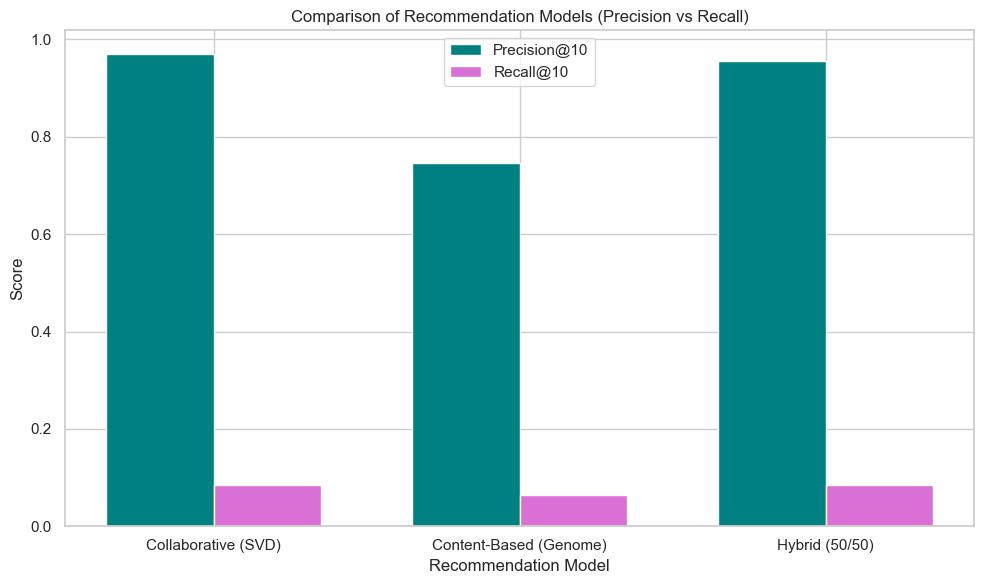

Comparison plot successfully generated and saved as "precision_recall_comparison.png".


In [6]:
plt.figure(figsize=(10, 6))
models = ['Collaborative (SVD)', 'Content-Based (Genome)', 'Hybrid (50/50)']
precisions = [avg_collab_p, avg_content_p, avg_hybrid_p]
recalls = [avg_collab_r, avg_content_r, avg_hybrid_r]

x = np.arange(len(models))
width = 0.35

plt.bar(x - width/2, precisions, width, label='Precision@10', color='teal')
plt.bar(x + width/2, recalls, width, label='Recall@10', color='orchid')

plt.title('Comparison of Recommendation Models (Precision vs Recall)')
plt.xlabel('Recommendation Model')
plt.ylabel('Score')
plt.xticks(x, models)
plt.legend()
plt.tight_layout()
plt.savefig('precision_recall_comparison.png', dpi=150)
plt.show()

print('Comparison plot successfully generated and saved as "precision_recall_comparison.png".')


### Step 7: Summary Comparison Table
Let's summarize key aspects of each filtering paradigm.


In [7]:
comparison_table = pd.DataFrame({
    'Model': ['Content-Based (Genre)', 'Content-Based (Genome)', 'Collaborative SVD', 'Hybrid Model'],
    'Personalization': ['Low', 'Medium', 'High', 'Very High'],
    'Handles Item Cold Start': ['Yes', 'Yes', 'No', 'Yes'],
    'Handles User Cold Start': ['Yes', 'Yes', 'No', 'No'],
    'Serendipity': ['Low', 'Low', 'High', 'High'],
    'Evaluation Metric (P@10)': ['Low', f'{avg_content_p:.3f}', f'{avg_collab_p:.3f}', f'{avg_hybrid_p:.3f}']
})
print('=== Final Recommendation Paradigm Comparison Table ===')
print(comparison_table.to_string(index=False))


=== Final Recommendation Paradigm Comparison Table ===
                 Model Personalization Handles Item Cold Start Handles User Cold Start Serendipity Evaluation Metric (P@10)
 Content-Based (Genre)             Low                     Yes                     Yes         Low                      Low
Content-Based (Genome)          Medium                     Yes                     Yes         Low                    0.746
     Collaborative SVD            High                      No                      No        High                    0.970
          Hybrid Model       Very High                     Yes                      No        High                    0.956
